# Mineração de Dados — Atividade prática de implementação do KNN

**Universidade Federal do Ceará · Departamento de Computação**
Disciplina de Mineração de Dados — Prof. José Macedo

---

* Samyra Vitória Lima de Almeida - 521240;
* Yasmin Santos de Amorim - 566326.

---


# 0 - Carregando Bibliotecas

In [17]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# 1 - Implementação do Algoritmo K-Nearest Neighbors (KNN)

Essa implementação utiliza a distância euclidiana como forma de calcular a distancia entre dois pontos

In [18]:
class KNN:
    """
    Implementação do algoritmo K-Nearest Neighbors
    """

    def __init__(self, k=3):
        """
        Inicializa o classificador KNN

        Parâmetros:
        -----------
        k : int
            Número de vizinhos mais próximos a considerar
        """
        if k < 1:
            raise ValueError("k deve ser >= 1")
        self.k = k
        self.X_train = None
        self.y_train = None

    def calcular_distancia(self, ponto1, ponto2):
        """
        Calcula a distância euclidiana
        """
        return np.sqrt(np.sum((ponto1 - ponto2) ** 2))

    def fit(self, X_train, y_train):
        """
        'Treina' o modelo (apenas armazena os dados de treino)

        No KNN não há treinamento real, apenas memorização dos dados
        """
        self.X_train = np.asarray(X_train, dtype=float)
        self.y_train = np.asarray(y_train)
        return self

    def _predict_um(self, x):
        """
        Prediz a classe de uma única amostra
        """
        # 1. Distância de x para todos os pontos de treino
        distancias = np.array([self.calcular_distancia(x, x_tr) for x_tr in self.X_train])

        # 2. Índices dos k vizinhos mais próximos
        #    (kind='stable' garante desempate determinístico pela ordem do treino)
        idx_vizinhos = np.argsort(distancias, kind="stable")[: self.k]

        # 3. Votação majoritária entre os rótulos dos vizinhos
        rotulos = self.y_train[idx_vizinhos]
        return Counter(rotulos).most_common(1)[0][0]

    def predict(self, X_test):
        """
        Prediz as classes para múltiplas amostras
        """
        X_test = np.asarray(X_test, dtype=float)
        return np.array([self._predict_um(x) for x in X_test])

    def score(self, X_test, y_test):
        """
        Calcula a acurácia do modelo
        """
        y_pred = self.predict(X_test)
        return np.mean(y_pred == np.asarray(y_test))


# 2 - Carregando dataset para treino/teste do Algoritmo KNN

In [19]:
# Carregar dados
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

print(f"\nDimensões do dataset: {X.shape}")
print(f"Número de amostras: {len(X)}")
print(f"Número de features: {X.shape[1]}")


Dimensões do dataset: (569, 30)
Número de amostras: 569
Número de features: 30


# 3 - Divisão do dataset em train e test

In [24]:
# Dividir dados
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalizar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nDimensões do dataset de treino: {X_train.shape}")
print(f"Número de amostras: {len(X_train)}")
print(f"Número de features: {X_train.shape[1]}")

print(f"\nDimensões do dataset de teste: {X_test.shape}")
print(f"Número de amostras: {len(X_test)}")
print(f"Número de features: {X_test.shape[1]}")


Dimensões do dataset de treino: (455, 30)
Número de amostras: 455
Número de features: 30

Dimensões do dataset de teste: (114, 30)
Número de amostras: 114
Número de features: 30


# 4 - Treino e teste do Modelo

## 4.1 - Treino simples do modelo

In [26]:
k = 5
knn = KNN(k=k)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"Acurácia: {acc:.4f} ({acc*100:.2f}%)")

Acurácia: 0.9561 (95.61%)


## 4.2 -  Com válidação cruzada

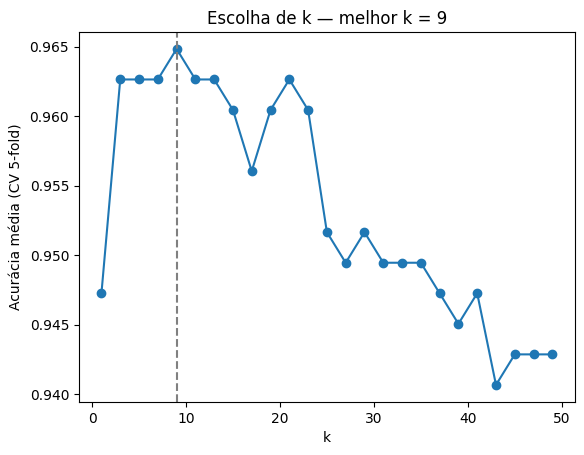

In [28]:

ks = range(1, 51, 2)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
medias = []

for k in ks:
    accs = []
    for tr, val in skf.split(X_train, y_train):
        sc = StandardScaler().fit(X_train[tr])          # normaliza dentro do fold
        modelo = KNN(k=k).fit(sc.transform(X_train[tr]), y_train[tr])
        accs.append(modelo.score(sc.transform(X_train[val]), y_train[val]))
    medias.append(np.mean(accs))

melhor_k = list(ks)[int(np.argmax(medias))]
plt.plot(ks, medias, marker="o")
plt.axvline(melhor_k, ls="--", c="gray")
plt.xlabel("k"); plt.ylabel("Acurácia média (CV 5-fold)")
plt.title(f"Escolha de k — melhor k = {melhor_k}")
plt.show()


# 4.3 Avaliação final no teste com o k escolhido

In [29]:
knn = KNN(k=melhor_k).fit(X_train_scaled, y_train)
print(f"Acurácia no teste (k={melhor_k}): {knn.score(X_test_scaled, y_test):.4f}")

Acurácia no teste (k=9): 0.9737
